# Import Libraries

In [35]:
import numpy as np
import pandas as pd

## Data loading

In [36]:
df = pd.read_excel('SKUForecastDataSet.xlsx')

In [37]:
df.head()

,ProductFamily,order_id,OrderDate,Channel,OrderSource,SKU,SKU_Description,ShipToState,WareHouseQuanity,SKU_category
0,AirDoctor,38191,2023-01-01,organic_social,WEB,90AD350AD01,Air Doctor AD3500,MD,1.0,Main Units
1,AirDoctor,38197,2023-01-01,email,WEB,90AD550AD01,Air Doctor AD5500,CO,1.0,Main Units
2,AirDoctor,38226,2023-01-01,paid_social,WEB,90AD350AD01,Air Doctor AD3500,IL,2.0,Main Units
3,AirDoctor,38235,2023-01-01,email,WEB,30AD01B003,AD5500+AD3500 Bundle,MD,1.0,Bundles
4,AirDoctor,38235,2023-01-01,email,WEB,90AD350AD01,Air Doctor AD3500,MD,1.0,Main Units


In [38]:
df.shape

(858258, 10)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858258 entries, 0 to 858257
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   ProductFamily     858258 non-null  object        
 1   order_id          858258 non-null  int64         
 2   OrderDate         858258 non-null  datetime64[ns]
 3   Channel           858258 non-null  object        
 4   OrderSource       858258 non-null  object        
 5   SKU               842028 non-null  object        
 6   SKU_Description   858258 non-null  object        
 7   ShipToState       857852 non-null  object        
 8   WareHouseQuanity  777308 non-null  float64       
 9   SKU_category      755942 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(7)
memory usage: 65.5+ MB


In [40]:
df.describe()

,order_id,OrderDate,WareHouseQuanity
count,8.582580e+05,858258,777308.000000
mean,7.237106e+05,2024-07-01 10:42:15.399845120,1.215491
min,3.683000e+04,2022-12-24 00:00:00,1.000000
25%,1.935790e+05,2023-11-24 00:00:00,1.000000
50%,4.053860e+05,2024-08-11 00:00:00,1.000000
75%,5.652810e+05,2025-01-30 00:00:00,1.000000
max,1.001882e+07,2025-07-17 00:00:00,40.000000
std,1.832057e+06,NaN,0.566094


In [41]:
print(df.nunique())

ProductFamily            1
order_id            461273
OrderDate              935
Channel                 22
OrderSource              6
SKU                    141
SKU_Description        214
ShipToState             95
WareHouseQuanity        24
SKU_category             5
dtype: int64


In [42]:
print(df.isnull().sum())

ProductFamily            0
order_id                 0
OrderDate                0
Channel                  0
OrderSource              0
SKU                  16230
SKU_Description          0
ShipToState            406
WareHouseQuanity     80950
SKU_category        102316
dtype: int64


## Data Visualization

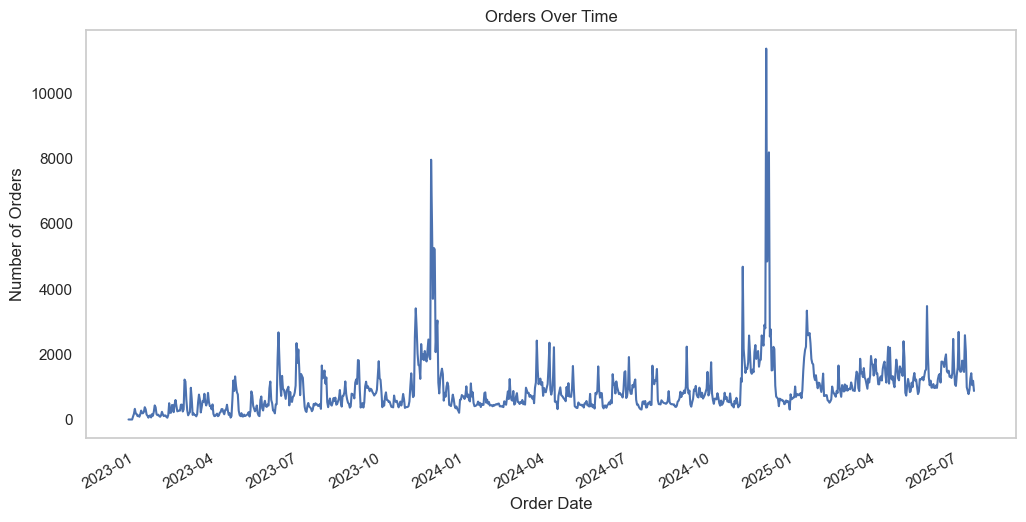

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Order distribution by date
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
plt.figure(figsize=(12,6))
df.groupby('OrderDate').size().plot(title='Orders Over Time')
plt.xlabel('Order Date')
plt.ylabel('Number of Orders')
plt.grid()
plt.show()


## Total Order Count by Channels

In [45]:
df['Channel'].value_counts()

Channel
email                  278605
Main                   272939
affiliate_social       113338
paid_search             93762
affiliate_email         29051
affiliates              26860
affiliate_publisher      9828
organic_social           9337
paid_social              8581
organic                  7253
TRN_DRTESF               2770
Drop Shipper             1438
customer_service         1406
TV                       1290
Paid_Search               627
other                     318
LVP_DRTESF                257
Email                     236
TRN_DRTELF                144
affiliate                 135
podcast                    55
native                     28
Name: count, dtype: int64

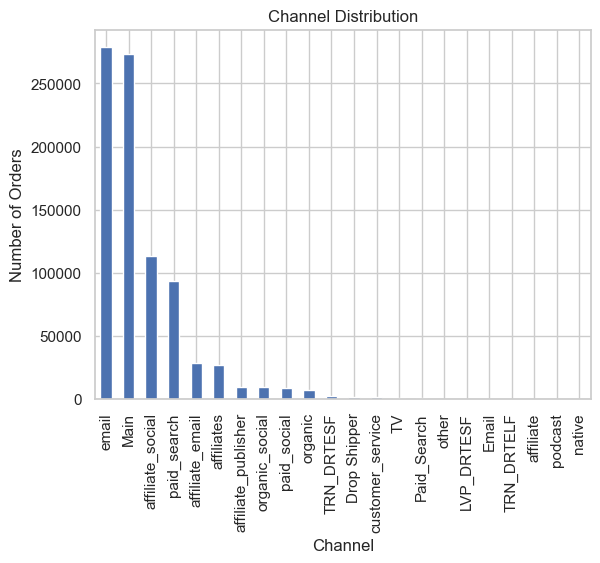

In [46]:
df['Channel'].value_counts().plot(kind='bar', title='Channel Distribution')
plt.xlabel('Channel')
plt.ylabel('Number of Orders')
plt.show()

### Order Source Analysis

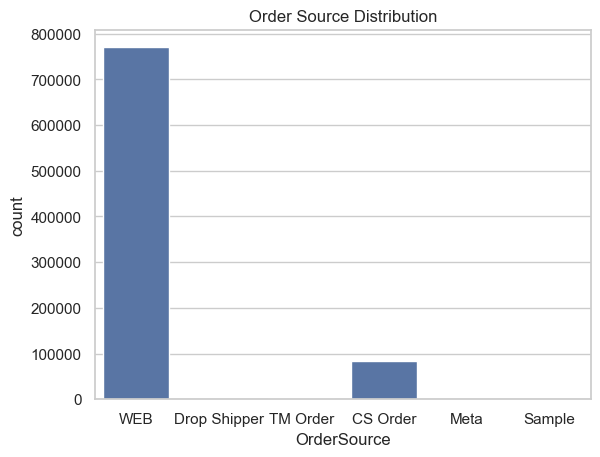

In [47]:
sns.countplot(x='OrderSource', data=df)
plt.title('Order Source Distribution')
plt.show()

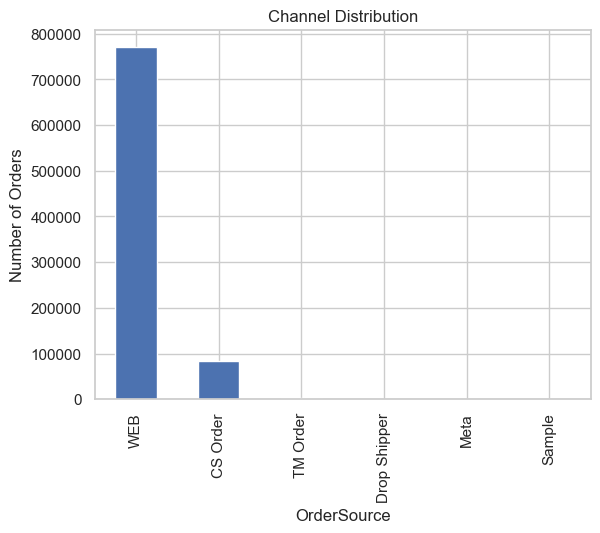

In [48]:
df['OrderSource'].value_counts().plot(kind='bar', title='Channel Distribution')
plt.xlabel('OrderSource')
plt.ylabel('Number of Orders')
plt.show()

## SKU Category and SKU Description

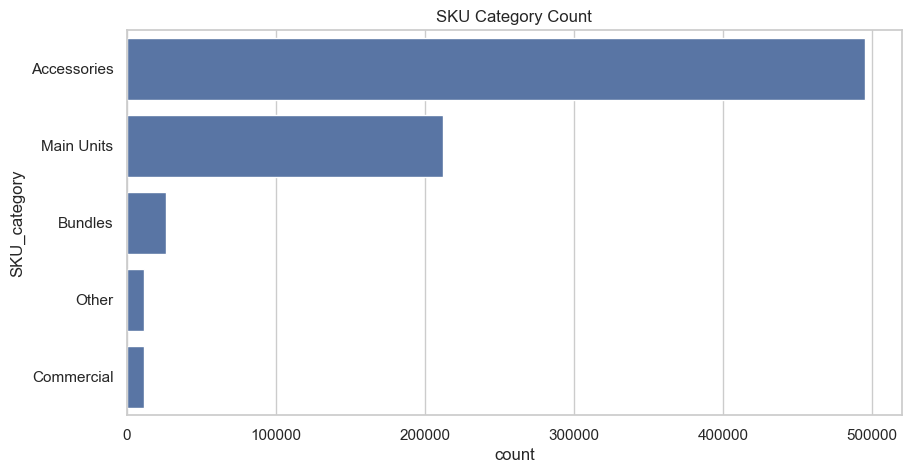

In [49]:
plt.figure(figsize=(10,5))
sns.countplot(y='SKU_category', data=df, order=df['SKU_category'].value_counts().index)
plt.title('SKU Category Count')
plt.show()




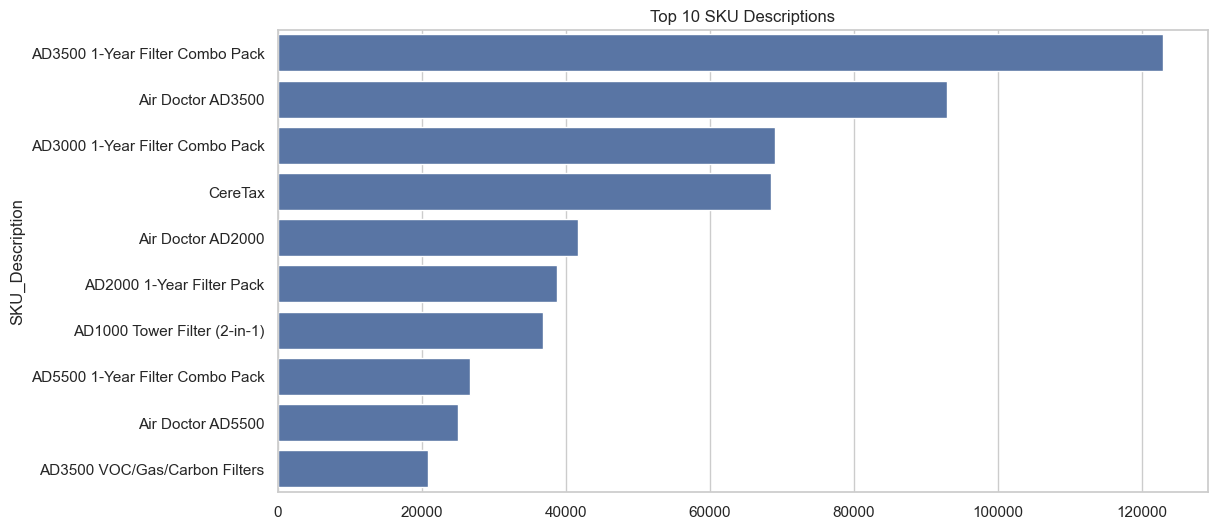

In [50]:
plt.figure(figsize=(12,6))
top_skus = df['SKU_Description'].value_counts().nlargest(10)
sns.barplot(y=top_skus.index, x=top_skus.values)
plt.title('Top 10 SKU Descriptions')
plt.show()

### Warehouse Quantity Distribution

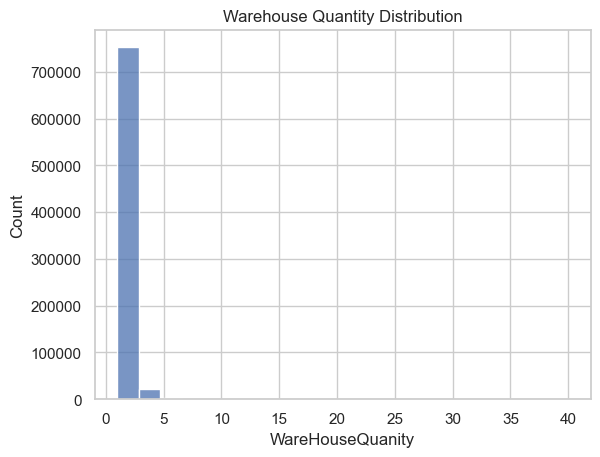

In [ ]:
sns.histplot(df['WareHouseQuanity'], kde=False)
plt.title('Warehouse Quantity Distribution')
plt.show()

### Geographic Distribution (ShipToState)

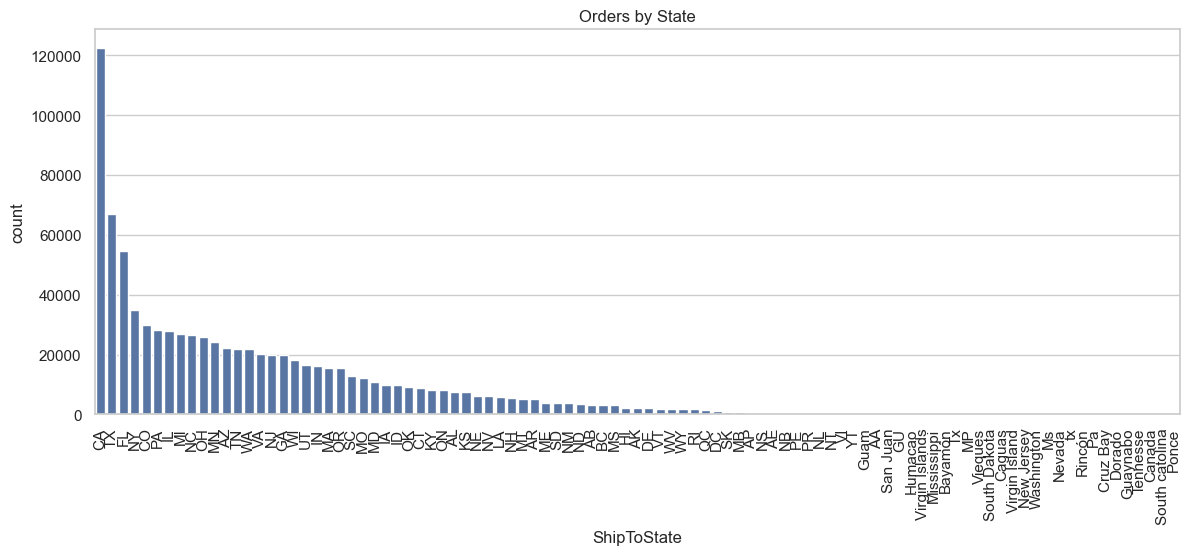

In [52]:
plt.figure(figsize=(14,5))
sns.countplot(x='ShipToState', data=df, order=df['ShipToState'].value_counts().index)
plt.title('Orders by State')
plt.xticks(rotation=90)
plt.show()


In [53]:
total_count=df['ShipToState'].value_counts().nlargest(10)
print(total_count)

ShipToState
CA    122494
TX     67080
FL     54697
NY     35048
CO     29957
PA     28312
IL     27854
MI     26802
NC     26392
OH     25715
Name: count, dtype: int64


### Monthly Value Trends

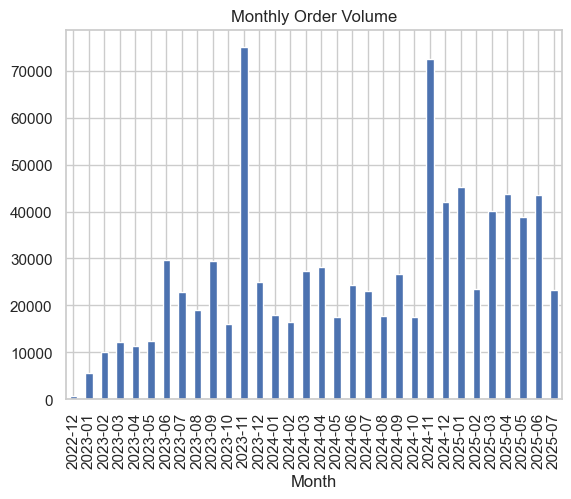

In [55]:
df['Month'] = df['OrderDate'].dt.to_period('M')
monthly_trend = df.groupby('Month').size()
monthly_trend.plot(kind='bar', title='Monthly Order Volume')
plt.show()


C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_43552\4119952867.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=monthly_trend, x='Month', y='OrderCount', palette=palette)
C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_43552\4119952867.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  barplot.set_xticklabels(barplot.get_xticklabels(), rotation=45, ha='right')


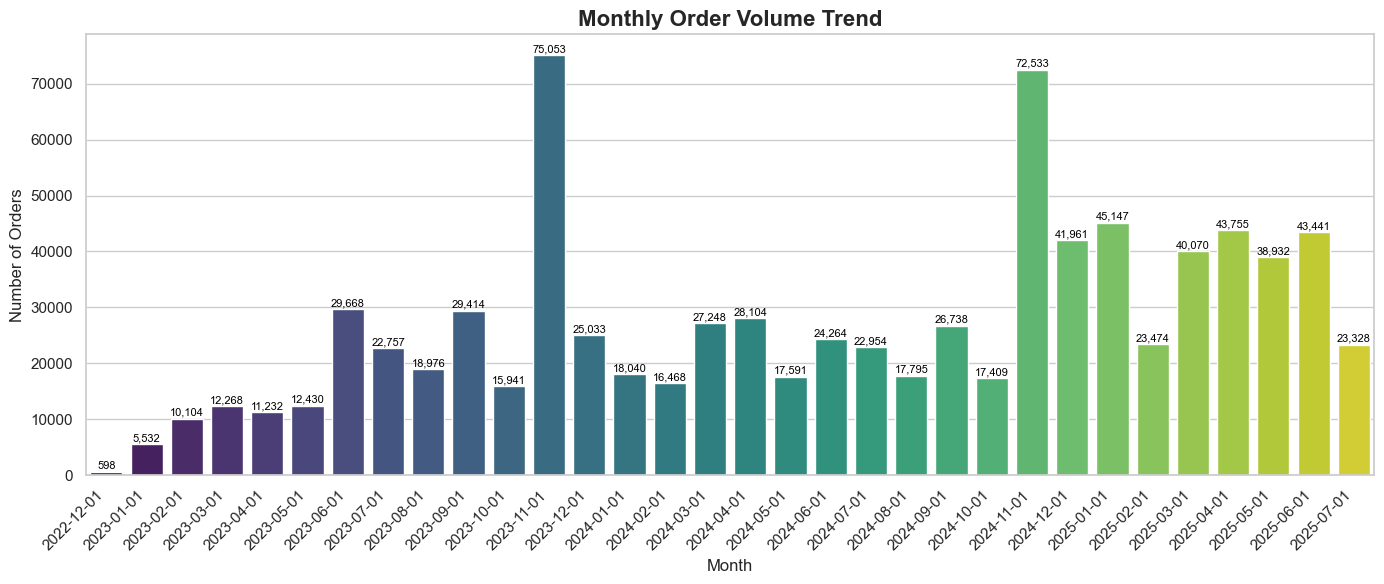

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'Month' is a datetime object
df['Month'] = df['OrderDate'].dt.to_period('M').dt.to_timestamp()
monthly_trend = df.groupby('Month').size().reset_index(name='OrderCount')

# Set theme and size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# Plot bar chart
palette = sns.color_palette("viridis", len(monthly_trend))
barplot = sns.barplot(data=monthly_trend, x='Month', y='OrderCount', palette=palette)

# Set titles and labels
plt.title("Monthly Order Volume Trend", fontsize=16, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

# Rotate x-axis labels for clarity
barplot.set_xticklabels(barplot.get_xticklabels(), rotation=45, ha='right')

# Annotate each bar
for index, row in monthly_trend.iterrows():
    barplot.text(index, row.OrderCount + 500, f"{row.OrderCount:,}", color='black', ha='center', fontsize=8)

plt.tight_layout()
plt.show()


 ### Step 1: Prepare the data

In [1]:
import pandas as pd

# Convert OrderDate to datetime
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Create a 'Week' column
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)


NameError: name 'df' is not defined

### Step 2: Weekly Aggregation
a. Weekly Orders by SKU

In [59]:
weekly_sku = df.groupby(['Week', 'SKU'])['WareHouseQuanity'].count().reset_index(name='WeeklyOrders')


### b. Weekly Orders by Channel

In [60]:
weekly_channel = df.groupby(['Week', 'Channel'])['WareHouseQuanity'].count().reset_index(name='WeeklyOrders')


### c. Weekly Orders by ShipToState

In [61]:
weekly_state = df.groupby(['Week', 'ShipToState'])['WareHouseQuanity'].count().reset_index(name='WeeklyOrders')


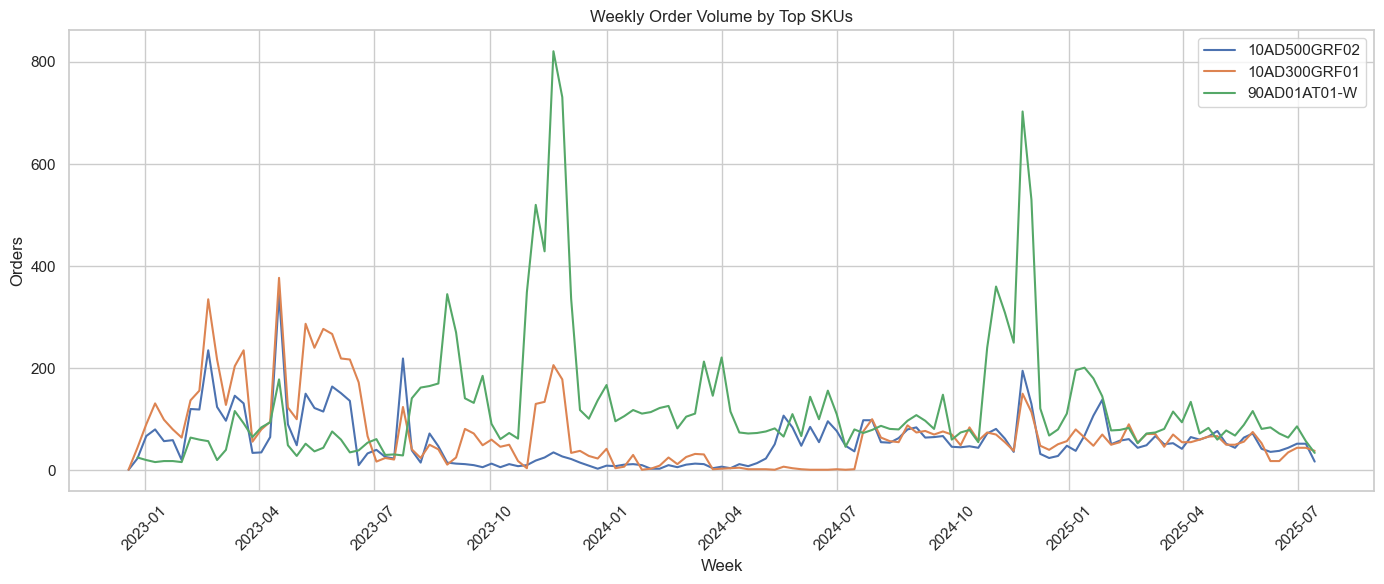

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter top N SKUs for clarity
top_skus = weekly_sku['SKU'].value_counts().nlargest(3).index
plt.figure(figsize=(14, 6))

for sku in top_skus:
    sku_data = weekly_sku[weekly_sku['SKU'] == sku]
    plt.plot(sku_data['Week'], sku_data['WeeklyOrders'], label=sku)

plt.title("Weekly Order Volume by Top SKUs")
plt.xlabel("Week")
plt.ylabel("Orders")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [31]:
# pip install prophet

14:42:49 - cmdstanpy - INFO - Chain [1] start processing
14:42:51 - cmdstanpy - INFO - Chain [1] done processing


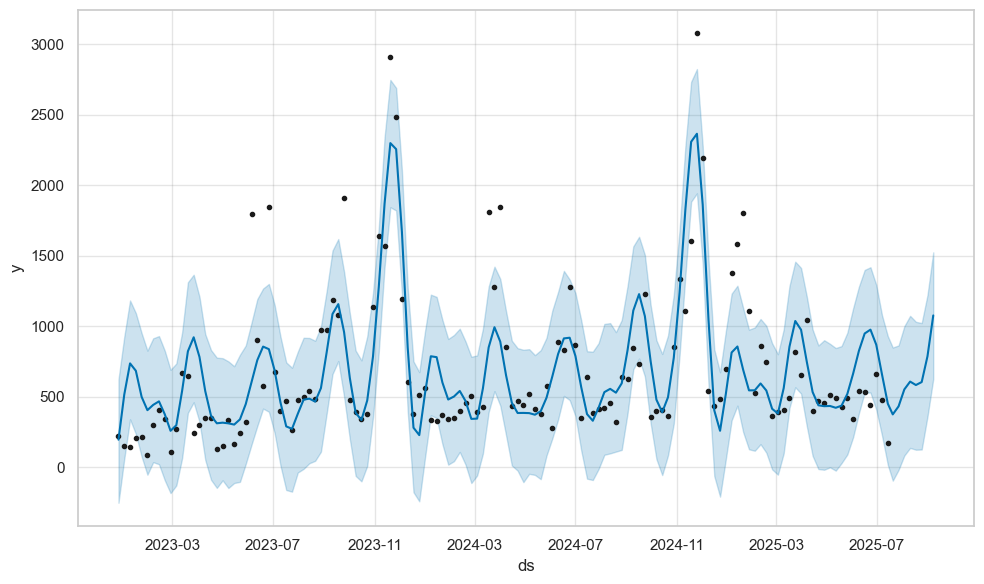

In [32]:
from prophet import Prophet

# Prepare data (e.g., for a single SKU)
sku_name = '90AD350AD01'
sku_data = weekly_sku[weekly_sku['SKU'] == sku_name][['Week', 'WeeklyOrders']].rename(columns={'Week': 'ds', 'WeeklyOrders': 'y'})

# Fit Prophet model
model = Prophet()
model.fit(sku_data)

# Future dataframe
future = model.make_future_dataframe(periods=8, freq='W')  # 8 weeks forecast
forecast = model.predict(future)

# Plot
fig = model.plot(forecast)


In [33]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2022-12-26,640.072536,-251.385536,623.889110,640.072536,640.072536,-444.116835,-444.116835,-444.116835,-444.116835,-444.116835,-444.116835,0.0,0.0,0.0,195.955701
1,2023-01-02,641.420243,60.009695,926.146340,641.420243,641.420243,-125.277837,-125.277837,-125.277837,-125.277837,-125.277837,-125.277837,0.0,0.0,0.0,516.142405
2,2023-01-09,642.767949,340.301648,1183.008713,642.767949,642.767949,94.115048,94.115048,94.115048,94.115048,94.115048,94.115048,0.0,0.0,0.0,736.882997
3,2023-01-16,644.115656,236.655585,1093.632779,644.115656,644.115656,40.439817,40.439817,40.439817,40.439817,40.439817,40.439817,0.0,0.0,0.0,684.555472
4,2023-01-23,645.463362,76.017670,951.504831,645.463362,645.463362,-145.897305,-145.897305,-145.897305,-145.897305,-145.897305,-145.897305,0.0,0.0,0.0,499.566057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,2025-08-10,797.166586,137.618302,1073.923519,797.128372,797.218055,-189.312416,-189.312416,-189.312416,-189.312416,-189.312416,-189.312416,0.0,0.0,0.0,607.854170
138,2025-08-17,798.093028,124.776675,1031.691474,798.033381,798.167087,-214.590804,-214.590804,-214.590804,-214.590804,-214.590804,-214.590804,0.0,0.0,0.0,583.502224
139,2025-08-24,799.019470,126.442303,1022.837610,798.936695,799.121637,-194.502082,-194.502082,-194.502082,-194.502082,-194.502082,-194.502082,0.0,0.0,0.0,604.517389
140,2025-08-31,799.945913,359.857015,1221.066179,799.837672,800.074715,-12.746512,-12.746512,-12.746512,-12.746512,-12.746512,-12.746512,0.0,0.0,0.0,787.199401


In [34]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

,ds,yhat,yhat_lower,yhat_upper
132,2025-07-07,657.400109,225.341595,1077.770268
133,2025-07-14,451.434382,17.767994,929.729378
134,2025-07-20,375.284830,-94.529651,849.487860
135,2025-07-27,431.983831,-18.251222,864.108592
136,2025-08-03,552.469695,83.797811,1000.384826
137,2025-08-10,607.854170,137.618302,1073.923519
138,2025-08-17,583.502224,124.776675,1031.691474
139,2025-08-24,604.517389,126.442303,1022.837610
140,2025-08-31,787.199401,359.857015,1221.066179
141,2025-09-07,1076.946601,626.396409,1524.265223
